<a href="https://colab.research.google.com/github/Karthikeya81/OPENCV_LAB_RECORD/blob/main/Experiment_12_OBJECT_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload a clear photo of a person's face (looking straight at the camera!):


Saving face.png to face.png

--- Detection Results ---
Blue = Face, Green = Eyes, Red = Smile


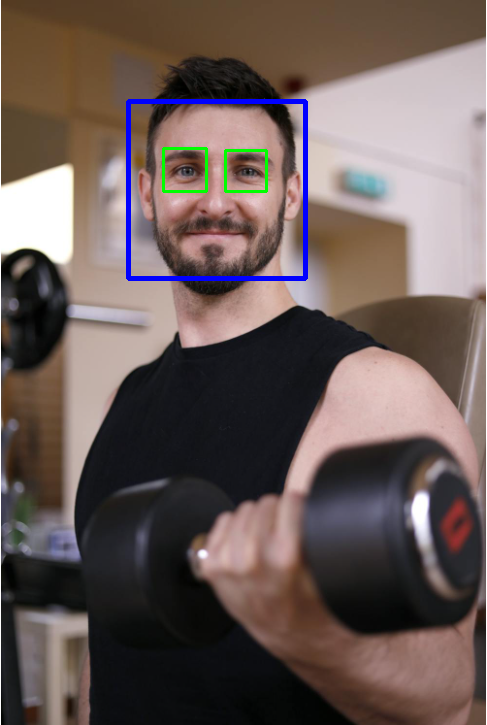

In [1]:
# Import the OpenCV library
import cv2
# Import the files module to upload our image
from google.colab import files
# Import the Colab-safe image display function
from google.colab.patches import cv2_imshow

print("Upload a clear photo of a person's face (looking straight at the camera!):")
# Prompt the user to upload an image
uploaded = files.upload()
# Grab the filename
filename = next(iter(uploaded))
# Read the uploaded image
image = cv2.imread(filename)

# Convert the image to grayscale (Haar Cascades require grayscale images to work)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- Load the Pre-trained Haar Cascade Models ---
# OpenCV comes with these XML files built-in. We access them using cv2.data.haarcascades
# 1. Load the Face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
# 2. Load the Eye detector
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
# 3. Load the Smile detector
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# --- Perform Detection ---
# detectMultiScale finds the objects.
# 1.3 is the scaleFactor (compensates for faces appearing smaller if they are far away)
# 5 is the minNeighbors (higher means it's more strict, reducing false positives)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

# Loop through every face detected. It gives us coordinates: x, y (top-left) and w, h (width, height)
for (x, y, w, h) in faces:
    # Draw a Blue rectangle around the face: (255, 0, 0)
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 3)

    # --- Region of Interest (ROI) ---
    # Eyes and smiles are INSIDE the face. So, we only need to search for them inside the face rectangle!
    # Create a grayscale ROI for detection, and a color ROI for drawing
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = image[y:y+h, x:x+w]

    # Detect Eyes within the face area
    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10)
    # Loop through detected eyes and draw Green rectangles: (0, 255, 0)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Detect Smiles within the face area
    # Smiles are tricky, so we use a high minNeighbors (like 20) to ensure it doesn't think a nose is a smile!
    smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.7, minNeighbors=20)
    # Loop through detected smiles and draw Red rectangles: (0, 0, 255)
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

# --- Display Results ---
print("\n--- Detection Results ---")
print("Blue = Face, Green = Eyes, Red = Smile")
# Show the final image with all the bounding boxes drawn on it
cv2_imshow(image)